In [1]:
!pip install nltk wordcloud seaborn -q

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

import nltk
from nltk.tokenize import word_tokenize
from nltk.util import bigrams, trigrams

from wordcloud import WordCloud

nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [41]:
df = df[
    ['speaker', 'year', 'text', 'words']
]

In [42]:
df = df.dropna(subset=['year'])

In [43]:
df['year'] = df['year'].astype(int)

In [44]:
df = df.drop_duplicates(
    subset=['text']
)

In [45]:
df = df[df['words'] > 50]

In [46]:
df.to_csv(
    "cleaned_political_speeches.csv",
    index=False
)

In [29]:
df = pd.read_csv('/content/cleaned_political_speeches.csv')

In [30]:
print(df.head())

print(df.columns)

print(df.info())

                speaker  year  \
0         Morarji Desai  1977   
1  Atal Bihari Vajpayee  1977   
2               Chandra  1977   
3  Atal Bihari Vajpayee  1977   
4     Babu Jagjiwan Ram  1977   

                                                text  words  \
0  What happened to two more sisters and brothers...    439   
1  What happened is that this era-changing work i...    130   
2  What happened was that Respected Morarji Bhai,...   1292   
3   That's what happened in this country, that fo...   1586   
4  Sisters and brothers, the last election was no...    477   

                                          clean_text  
0  what happened to two more sisters and brothers...  
1  what happened is that this erachanging work is...  
2  what happened was that respected morarji bhai ...  
3  thats what happened in this country that foot ...  
4  sisters and brothers the last election was not...  
Index(['speaker', 'year', 'text', 'words', 'clean_text'], dtype='object')
<class 'pandas.cor

In [31]:
print("Total speeches:", len(df))

Total speeches: 715


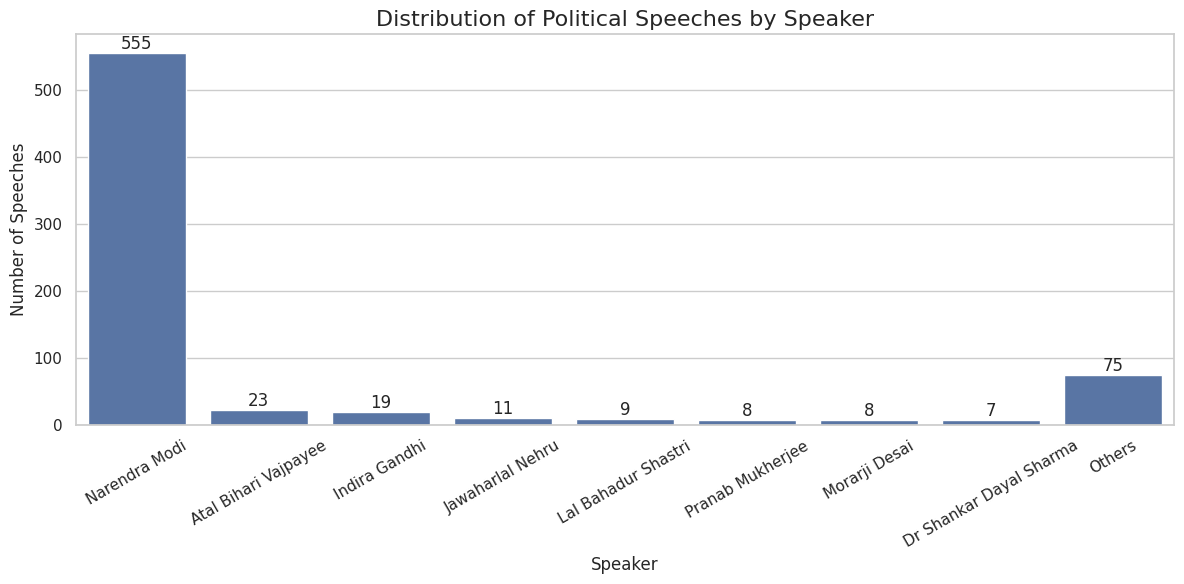

In [32]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Count speeches per speaker
speaker_counts = df['speaker'].value_counts()

# Keep only top speakers
top_n = 8

top_speakers = speaker_counts[:top_n]

# Combine remaining speakers into "Others"
others_count = speaker_counts[top_n:].sum()

final_counts = top_speakers.copy()

final_counts['Others'] = others_count

# Convert to dataframe
plot_df = pd.DataFrame({
    'Speaker': final_counts.index,
    'Count': final_counts.values
})

# Seaborn theme
sns.set_style("whitegrid")

# Plot
plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=plot_df,
    x='Speaker',
    y='Count'
)

# Add labels on bars
for i in ax.containers:
    ax.bar_label(i)

plt.title(
    "Distribution of Political Speeches by Speaker",
    fontsize=16
)

plt.xlabel("Speaker", fontsize=12)

plt.ylabel("Number of Speeches", fontsize=12)

plt.xticks(rotation=30)

plt.tight_layout()

plt.show()

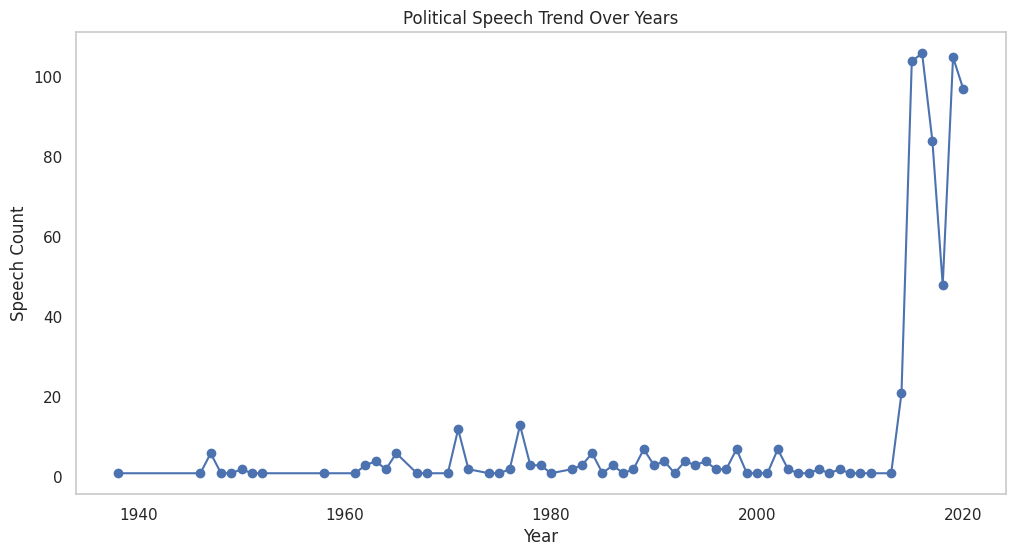

In [34]:
plt.figure(figsize=(12,6))

df['year'].value_counts().sort_index().plot(
    kind='line',
    marker='o'
)

plt.title("Political Speech Trend Over Years")

plt.xlabel("Year")

plt.ylabel("Speech Count")

plt.grid()

plt.show()

In [36]:
df['word_count'] = df['text'].apply(
    lambda x: len(str(x).split())
)

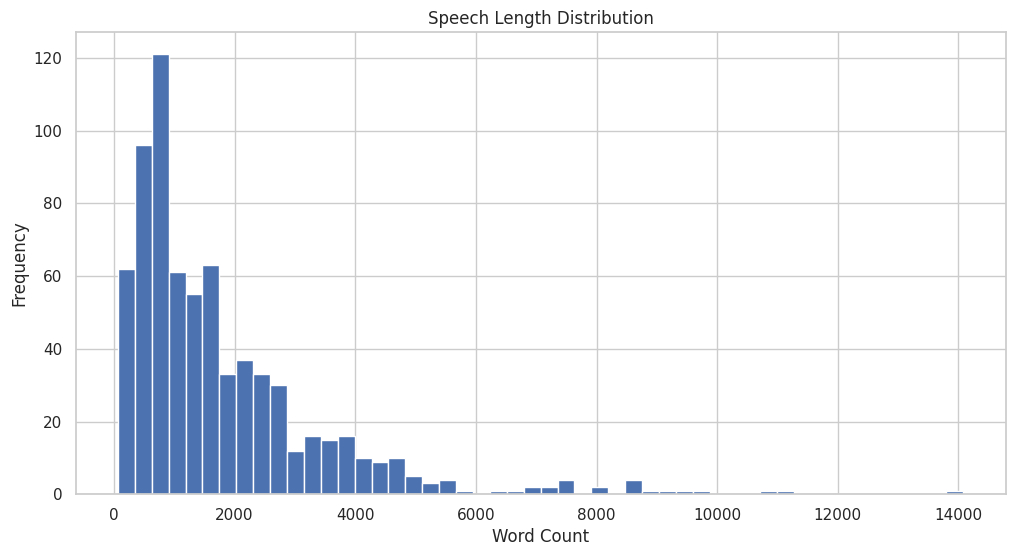

In [37]:
plt.figure(figsize=(12,6))

plt.hist(df['word_count'], bins=50)

plt.title("Speech Length Distribution")

plt.xlabel("Word Count")

plt.ylabel("Frequency")

plt.show()

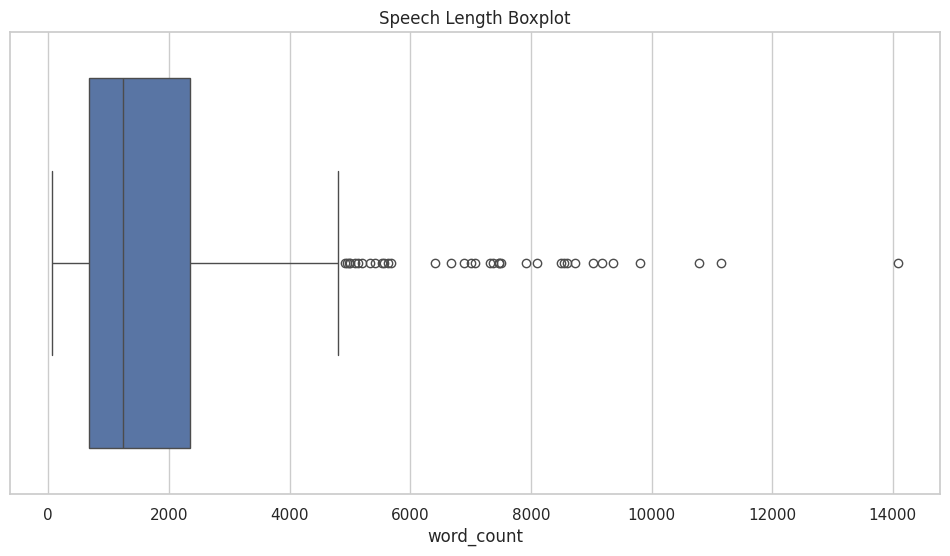

In [38]:
plt.figure(figsize=(12,6))

sns.boxplot(x=df['word_count'])

plt.title("Speech Length Boxplot")

plt.show()

In [39]:
import re
from nltk.corpus import stopwords

nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

all_words = []

for text in df['text']:

    # lowercase
    text = str(text).lower()

    # remove punctuation/numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # tokenize
    tokens = word_tokenize(text)

    # remove stopwords + short words
    tokens = [
        word for word in tokens
        if word not in stop_words
        and len(word) > 2
    ]

    all_words.extend(tokens)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [40]:
word_freq = Counter(all_words)

top_words = word_freq.most_common(20)

words = [w[0] for w in top_words]

counts = [w[1] for w in top_words]

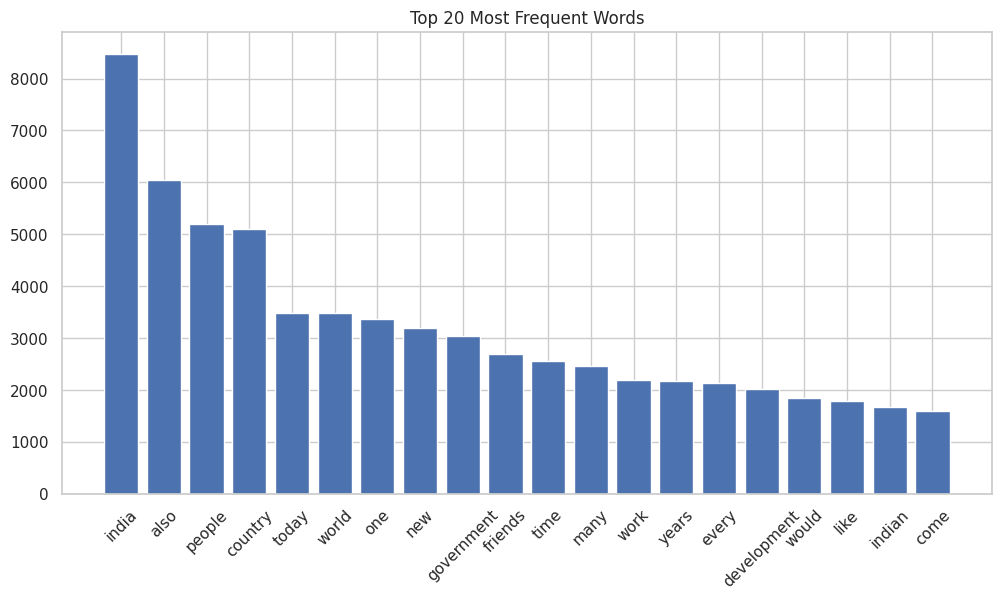

In [41]:
plt.figure(figsize=(12,6))

plt.bar(words, counts)

plt.title("Top 20 Most Frequent Words")

plt.xticks(rotation=45)

plt.show()

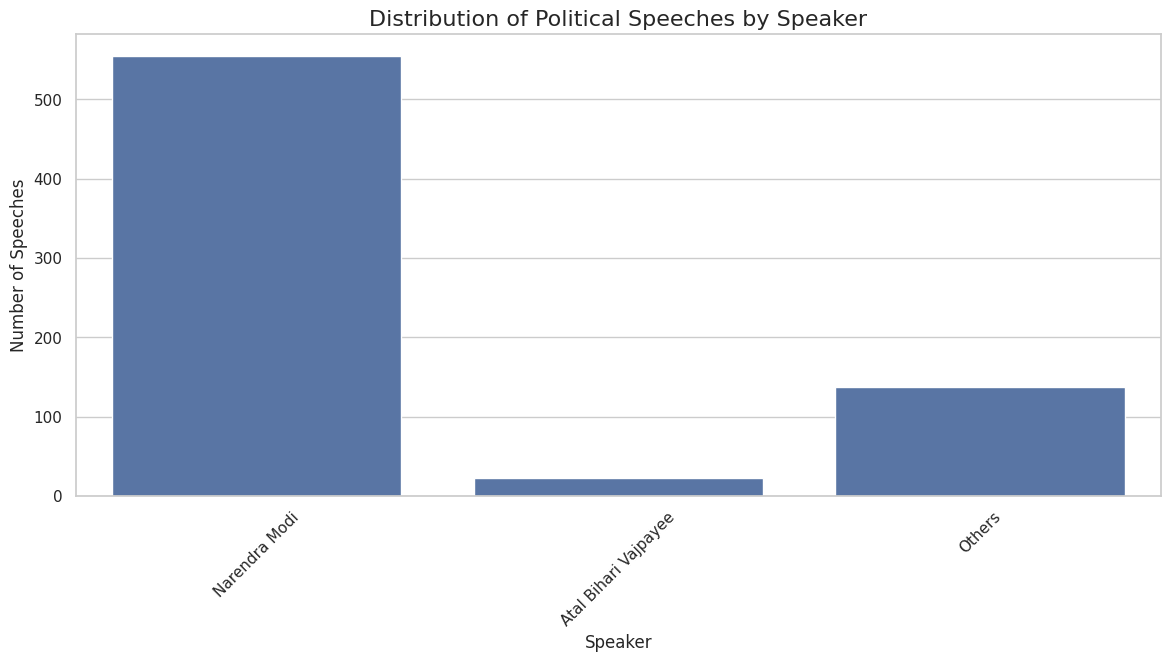

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('/content/cleaned_political_speeches.csv')

# Speaker counts
speaker_counts = df['speaker'].value_counts()

major_speakers = speaker_counts[speaker_counts > 20]

others_count = speaker_counts[speaker_counts <= 20].sum()

plot_data = major_speakers.copy()

plot_data['Others'] = others_count

plot_df = pd.DataFrame({
    'speaker': plot_data.index,
    'count': plot_data.values
})

# Plot
plt.figure(figsize=(14,6))

sns.barplot(
    data=plot_df,
    x='speaker',
    y='count'
)

plt.xticks(rotation=45)

plt.title(
    "Distribution of Political Speeches by Speaker",
    fontsize=16
)

plt.xlabel("Speaker")

plt.ylabel("Number of Speeches")

# Save plot
plt.savefig(
    '/content/speaker_distribution.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

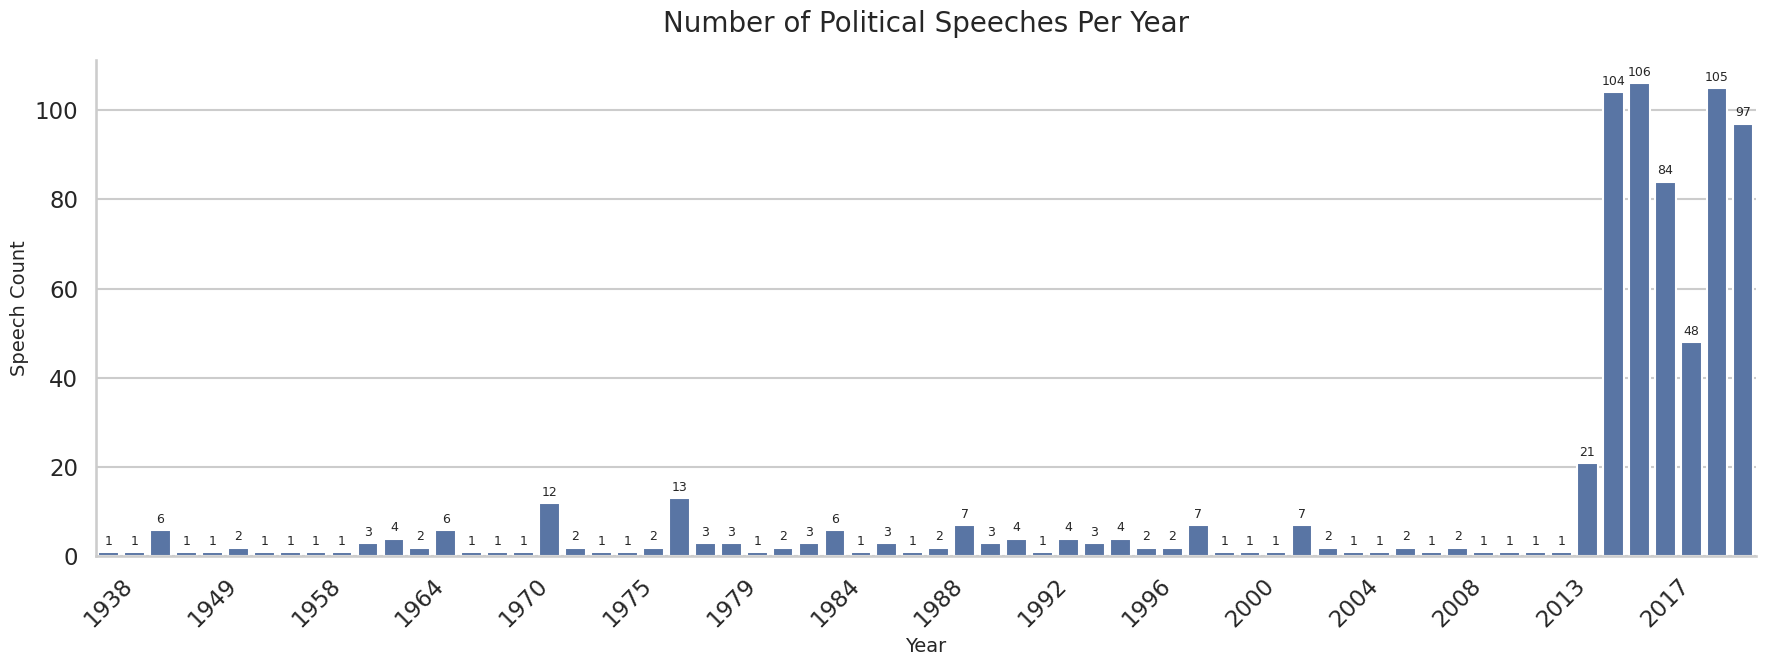

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('/content/cleaned_political_speeches.csv')

# Count speeches per year
year_counts = (
    df['year']
    .value_counts()
    .sort_index()
    .reset_index()
)

# Rename columns
year_counts.columns = ['Year', 'Speech_Count']

# Seaborn theme
sns.set_theme(
    style="whitegrid",
    context="talk"
)

# Create figure
plt.figure(figsize=(18,7))

# Seaborn barplot
ax = sns.barplot(
    data=year_counts,
    x='Year',
    y='Speech_Count'
)

# Show fewer x-axis labels for readability
ax.set_xticks(ax.get_xticks()[::4])

ax.set_xticklabels(
    year_counts['Year'][::4],
    rotation=45
)

# Add values on top of major bars only
for i in ax.containers:
    ax.bar_label(
        i,
        fontsize=9,
        padding=3
    )

# Titles and labels
plt.title(
    "Number of Political Speeches Per Year",
    fontsize=20,
    pad=20
)

plt.xlabel(
    "Year",
    fontsize=14
)

plt.ylabel(
    "Speech Count",
    fontsize=14
)

# Remove top/right borders
sns.despine()

# Tight layout
plt.tight_layout()

# Save figure
plt.savefig(
    '/content/clean_year_plot.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


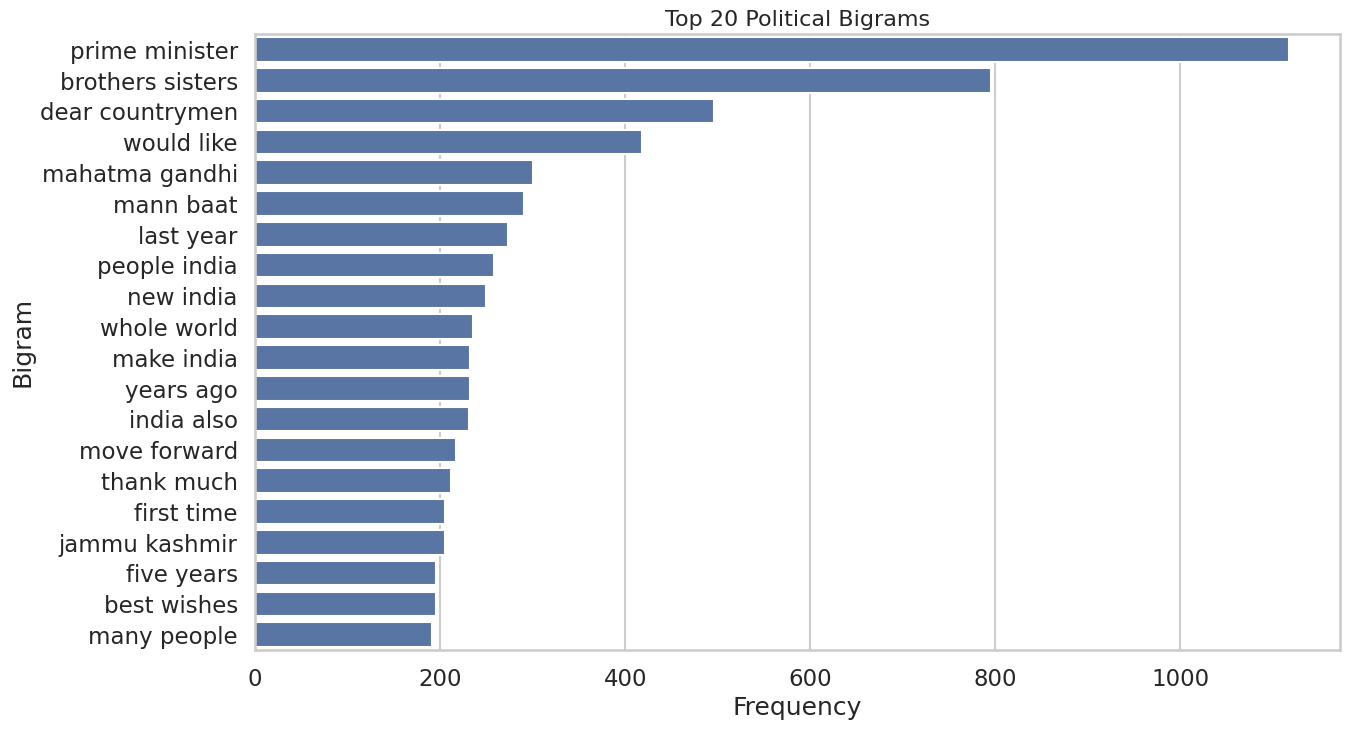

In [18]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import nltk
import re

import nltk

nltk.download('punkt')
nltk.download('punkt_tab')


from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.util import ngrams
from collections import Counter

nltk.download('punkt')
nltk.download('stopwords')

# Load dataset
df = pd.read_csv('/content/cleaned_political_speeches.csv')

# Stopwords
stop_words = set(stopwords.words('english'))

# Clean text
def clean_text(text):

    text = str(text).lower()

    text = re.sub(r"[^a-zA-Z\s]", "", text)

    return text

df['clean_text'] = df['text'].apply(clean_text)

# Tokenization
tokens = []

for text in df['clean_text']:

    words = word_tokenize(text)

    words = [
        word for word in words
        if word not in stop_words
        and len(word) > 2
    ]

    tokens.extend(words)

# Generate bigrams
bigrams_list = list(ngrams(tokens, 2))

bigram_freq = Counter(bigrams_list)

top_bigrams = bigram_freq.most_common(20)

# Dataframe
bigram_df = pd.DataFrame(
    top_bigrams,
    columns=['bigram', 'frequency']
)

bigram_df['bigram'] = bigram_df['bigram'].apply(
    lambda x: ' '.join(x)
)

# Plot
plt.figure(figsize=(14,8))

sns.barplot(
    data=bigram_df,
    x='frequency',
    y='bigram'
)

plt.title(
    "Top 20 Political Bigrams",
    fontsize=16
)

plt.xlabel("Frequency")

plt.ylabel("Bigram")

# Save plot
plt.savefig(
    '/content/bigrams.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

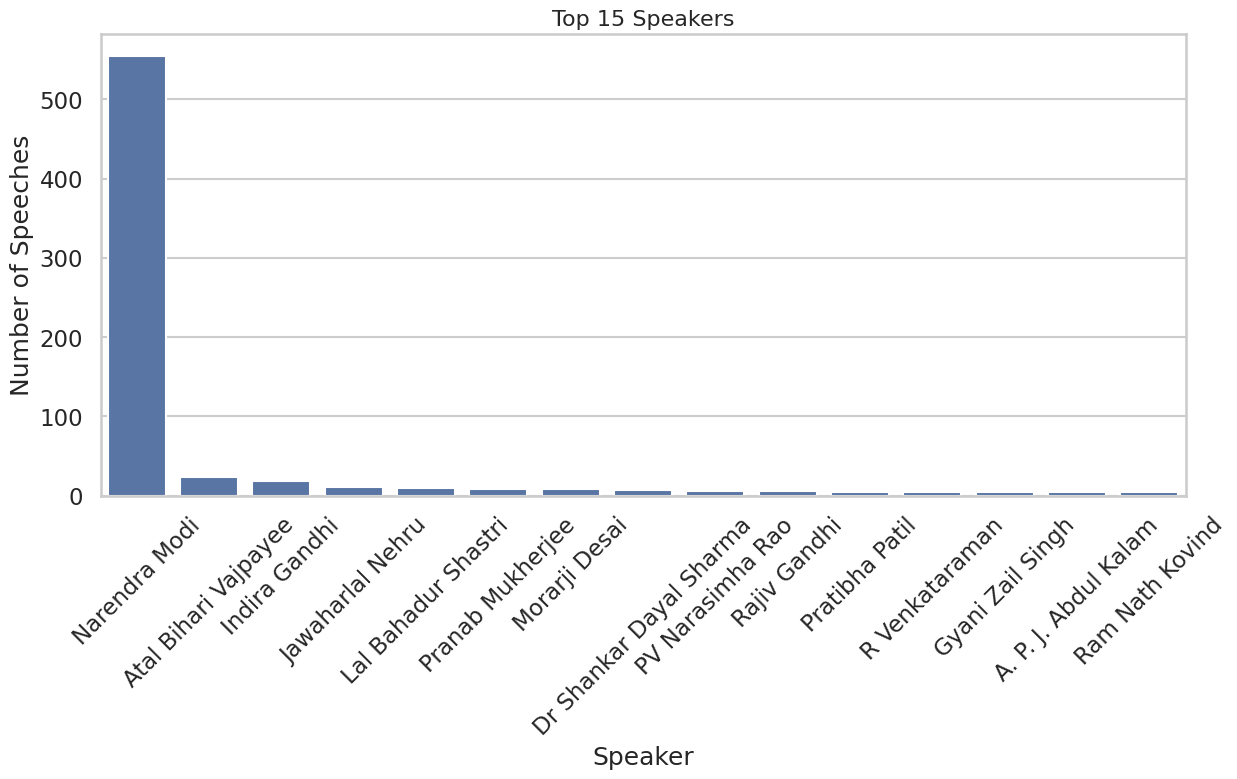

In [16]:

top_speakers = (
    df['speaker']
    .value_counts()
    .head(15)
    .reset_index()
)

top_speakers.columns = ['speaker', 'count']

plt.figure(figsize=(14,6))

sns.barplot(
    data=top_speakers,
    x='speaker',
    y='count'
)

plt.xticks(rotation=45)

plt.title(
    "Top 15 Speakers",
    fontsize=16
)

plt.xlabel("Speaker")

plt.ylabel("Number of Speeches")

plt.show()


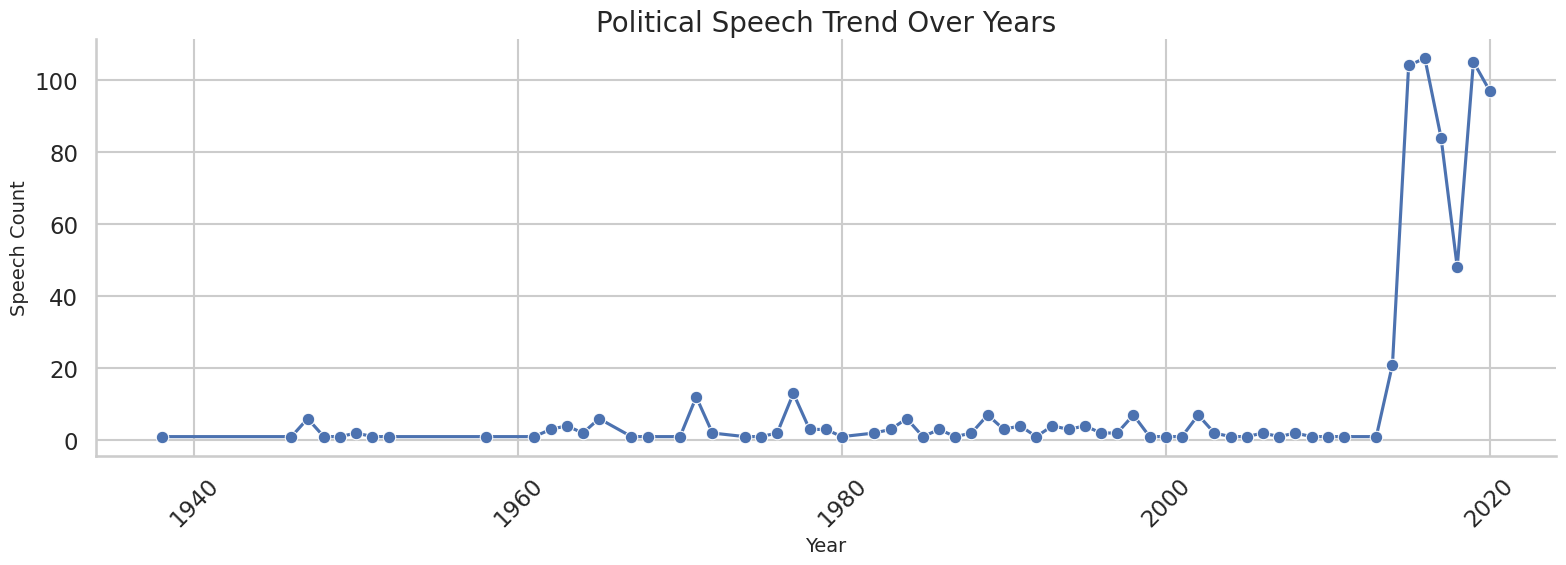

In [20]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('/content/cleaned_political_speeches.csv')

# Count speeches per year
year_counts = (
    df['year']
    .value_counts()
    .sort_index()
    .reset_index(name='Speech_Count')
)

# Rename year column
year_counts.columns = ['Year', 'Speech_Count']

# Seaborn theme
sns.set_theme(
    style="whitegrid",
    context="talk"
)

# Plot
plt.figure(figsize=(16,6))

sns.lineplot(
    data=year_counts,
    x='Year',
    y='Speech_Count',
    marker='o'
)

plt.title(
    "Political Speech Trend Over Years",
    fontsize=20
)

plt.xlabel(
    "Year",
    fontsize=14
)

plt.ylabel(
    "Speech Count",
    fontsize=14
)

plt.xticks(rotation=45)

sns.despine()

plt.tight_layout()

plt.show()

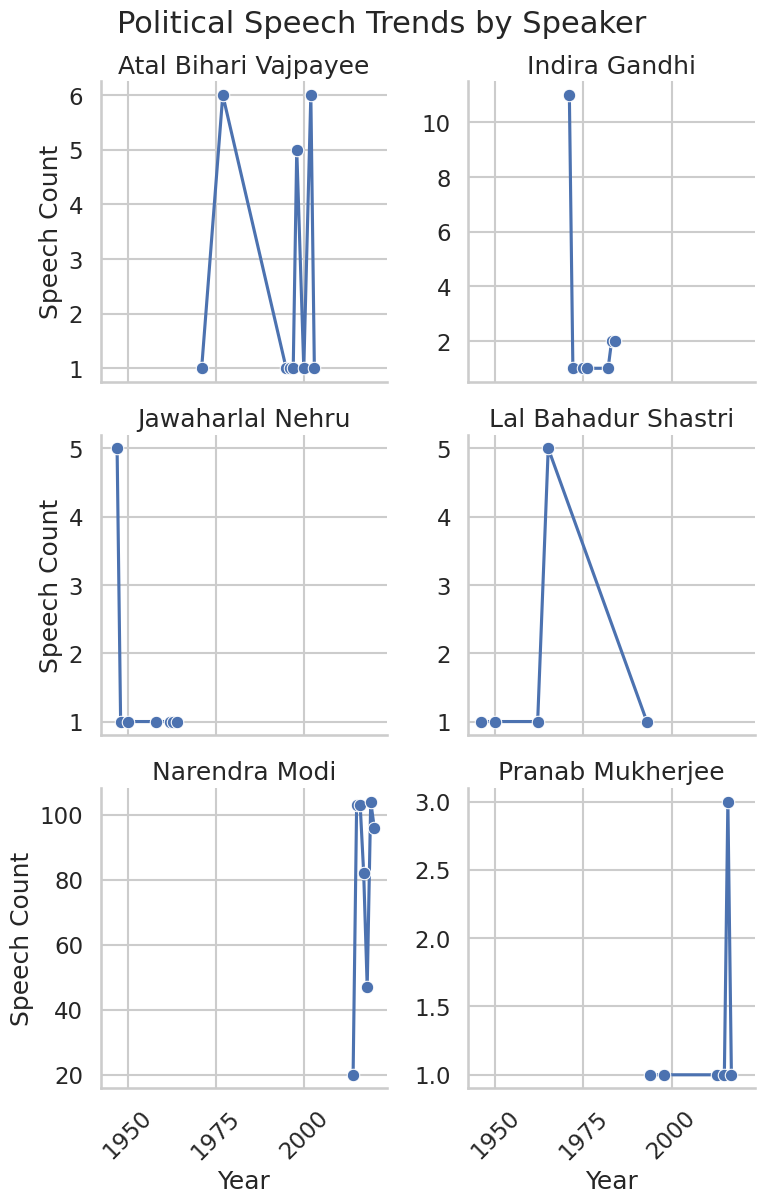

In [45]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('/content/cleaned_political_speeches.csv')

# Top speakers only
top_speakers = (
    df['speaker']
    .value_counts()
    .head(6)
    .index
)

filtered_df = df[
    df['speaker'].isin(top_speakers)
]

# Count speeches per year
speaker_year = (
    filtered_df
    .groupby(['speaker', 'year'])
    .size()
    .reset_index(name='Speech_Count')
)

# Seaborn theme
sns.set_theme(
    style="whitegrid",
    context="talk"
)

# Facet grid
g = sns.FacetGrid(
    speaker_year,
    col='speaker',
    col_wrap=2,
    height=4,
    sharey=False
)

# Plot lines
g.map_dataframe(
    sns.lineplot,
    x='year',
    y='Speech_Count',
    marker='o'
)

# Titles and labels
g.set_axis_labels(
    "Year",
    "Speech Count"
)

g.set_titles("{col_name}")

# Rotate x labels
for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=45)

# Overall title
g.fig.suptitle(
    "Political Speech Trends by Speaker",
    fontsize=22
)

g.fig.subplots_adjust(top=0.92)

plt.show()

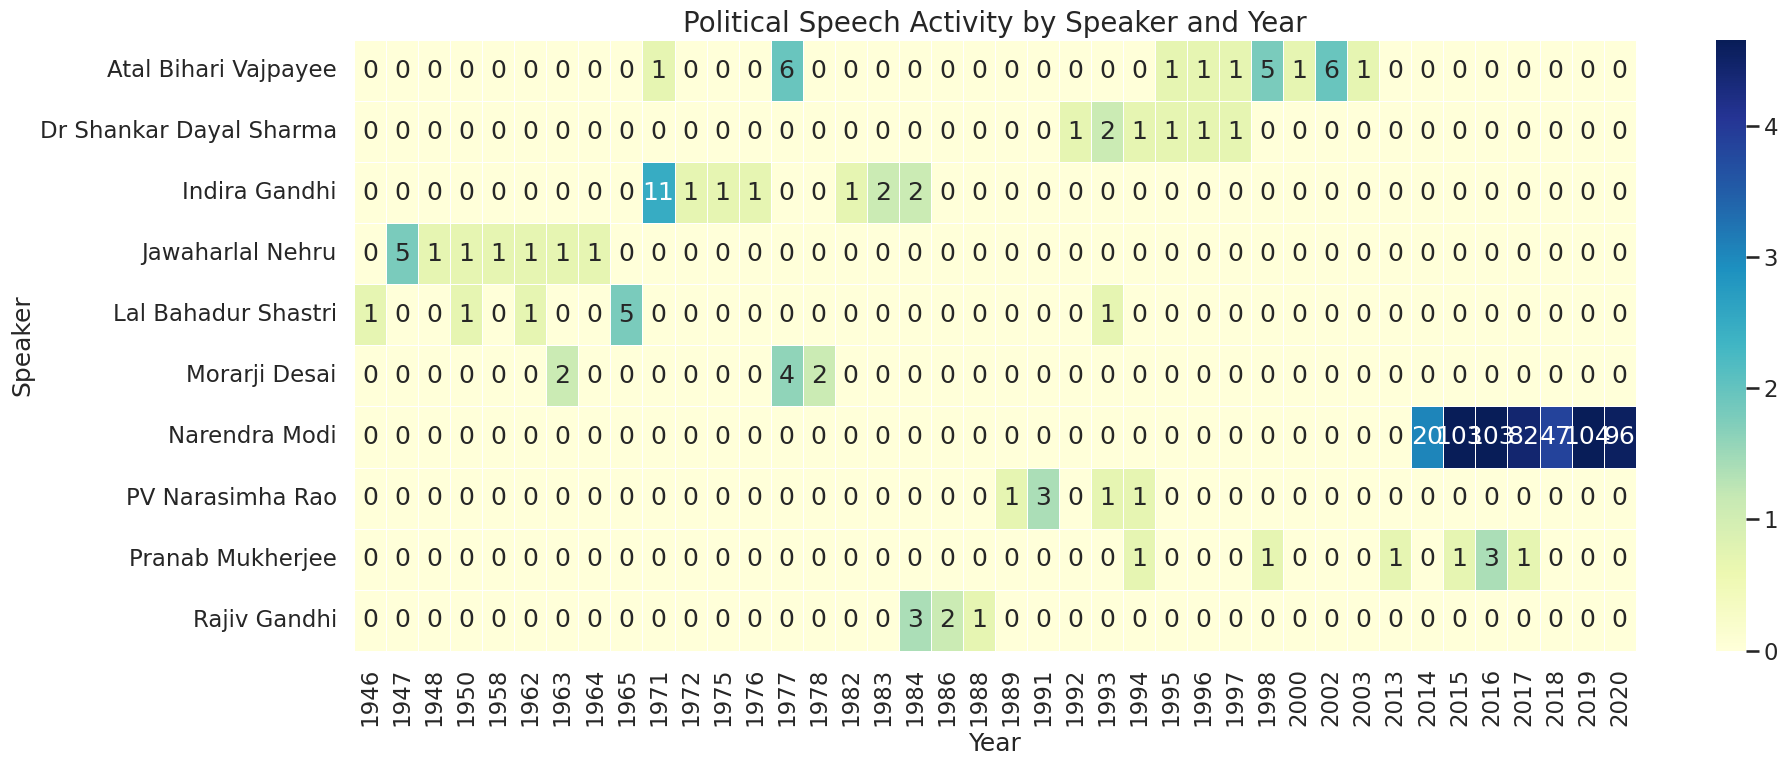

In [47]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Load dataset
df = pd.read_csv('/content/cleaned_political_speeches.csv')

# Top speakers
top_speakers = (
    df['speaker']
    .value_counts()
    .head(10)
    .index
)

filtered_df = df[
    df['speaker'].isin(top_speakers)
]

# Crosstab
heatmap_data = pd.crosstab(
    filtered_df['speaker'],
    filtered_df['year']
)

# Apply log scaling
heatmap_log = np.log1p(heatmap_data)

# Plot
plt.figure(figsize=(20,8))

sns.heatmap(
    heatmap_log,
    cmap='YlGnBu',
    linewidths=0.5,
    annot=heatmap_data,
    fmt='d'
)

plt.title(
    "Political Speech Activity by Speaker and Year",
    fontsize=20
)

plt.xlabel("Year")

plt.ylabel("Speaker")

plt.tight_layout()

plt.show()

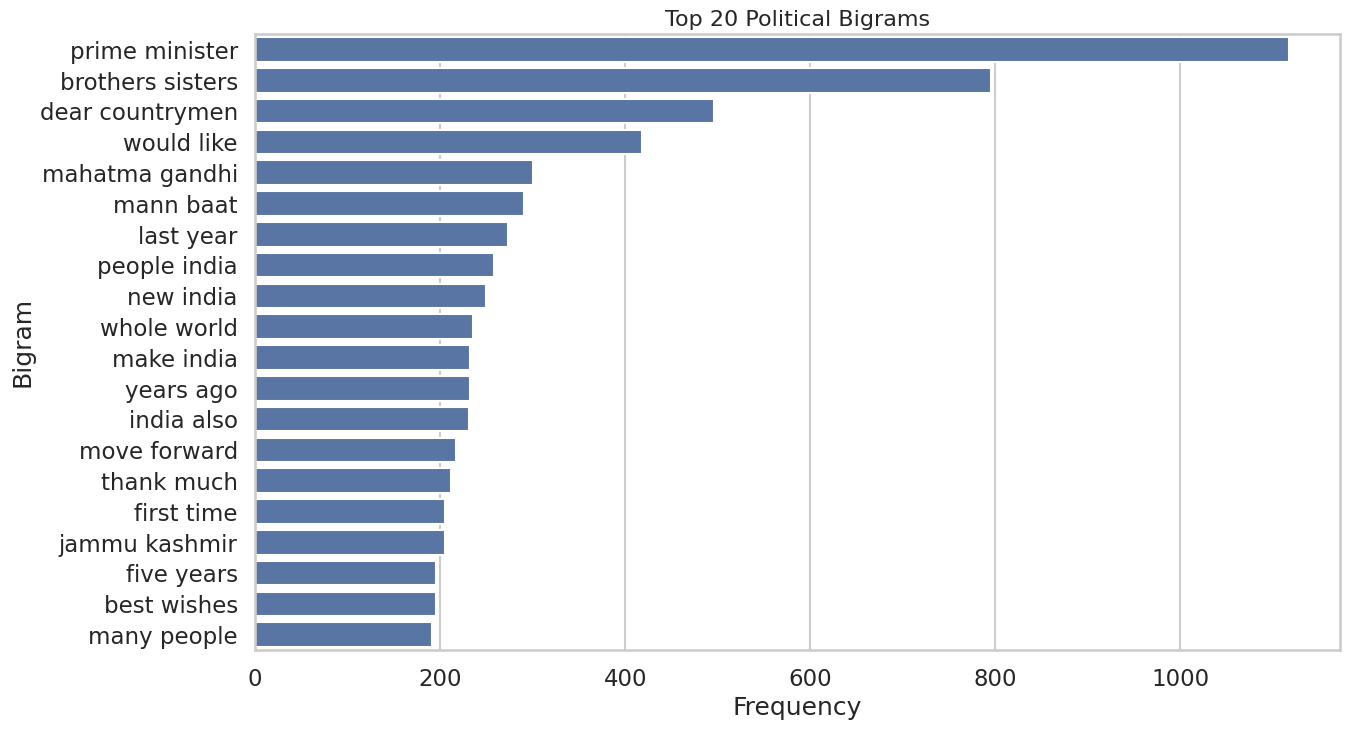

In [21]:


# ============================================================
# TOKENIZATION
# ============================================================

tokens = []

for text in df['clean_text']:

    words = word_tokenize(text)

    words = [
        word for word in words
        if word not in stop_words
        and len(word) > 2
    ]

    tokens.extend(words)

# ============================================================
# BIGRAM ANALYSIS
# ============================================================

bigrams_list = list(ngrams(tokens, 2))

bigram_freq = Counter(bigrams_list)

top_bigrams = bigram_freq.most_common(20)

bigram_df = pd.DataFrame(
    top_bigrams,
    columns=['bigram', 'frequency']
)

bigram_df['bigram'] = bigram_df['bigram'].apply(
    lambda x: ' '.join(x)
)

plt.figure(figsize=(14,8))

sns.barplot(
    data=bigram_df,
    x='frequency',
    y='bigram'
)

plt.title(
    "Top 20 Political Bigrams",
    fontsize=16
)

plt.xlabel("Frequency")

plt.ylabel("Bigram")

plt.show()





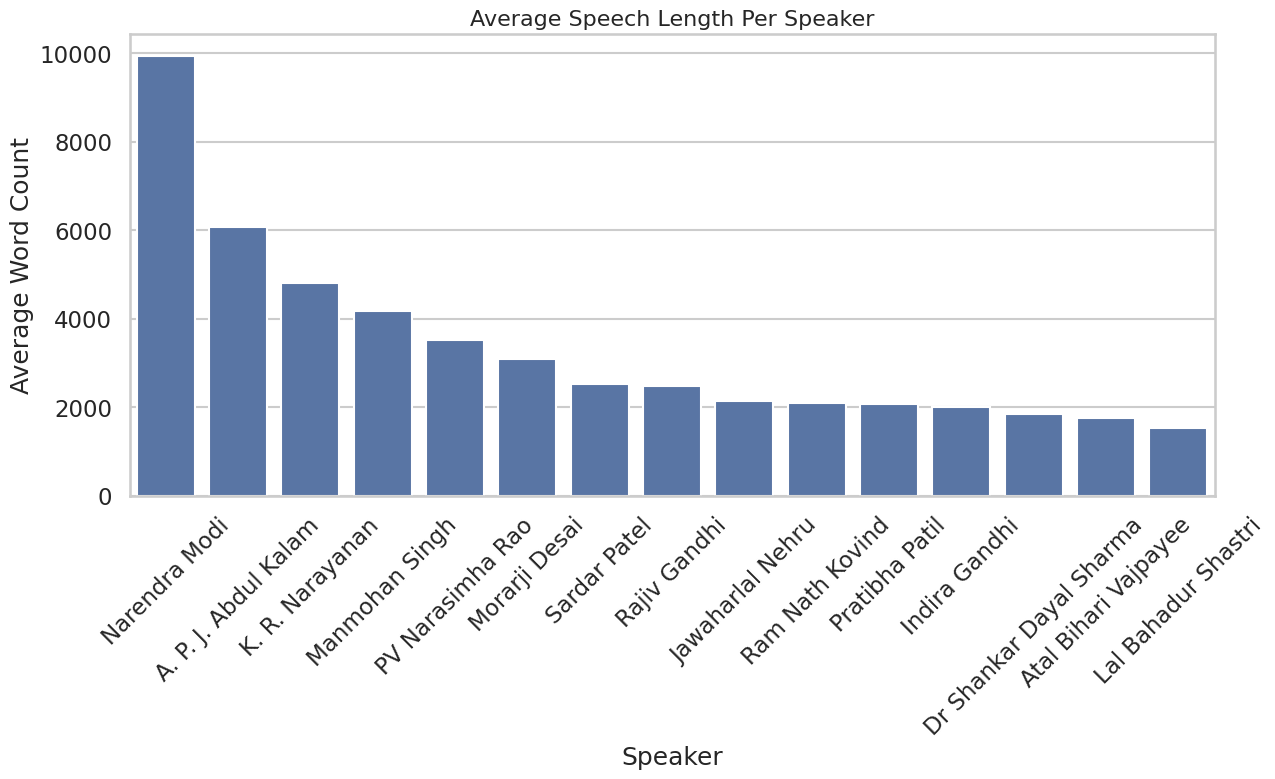

Cleaned dataset saved successfully.


In [22]:








# ============================================================
# AVERAGE SPEECH LENGTH PER SPEAKER
# ============================================================

avg_length = (
    df.groupby('speaker')['words']
    .mean()
    .sort_values(ascending=False)
    .head(15)
    .reset_index()
)

plt.figure(figsize=(14,6))

sns.barplot(
    data=avg_length,
    x='speaker',
    y='words'
)

plt.xticks(rotation=45)

plt.title(
    "Average Speech Length Per Speaker",
    fontsize=16
)

plt.xlabel("Speaker")

plt.ylabel("Average Word Count")

plt.show()

# ============================================================
# SAVE CLEANED DATASET
# ============================================================

df.to_csv(
    '/content/cleaned_political_speeches.csv',
    index=False
)

print("Cleaned dataset saved successfully.")

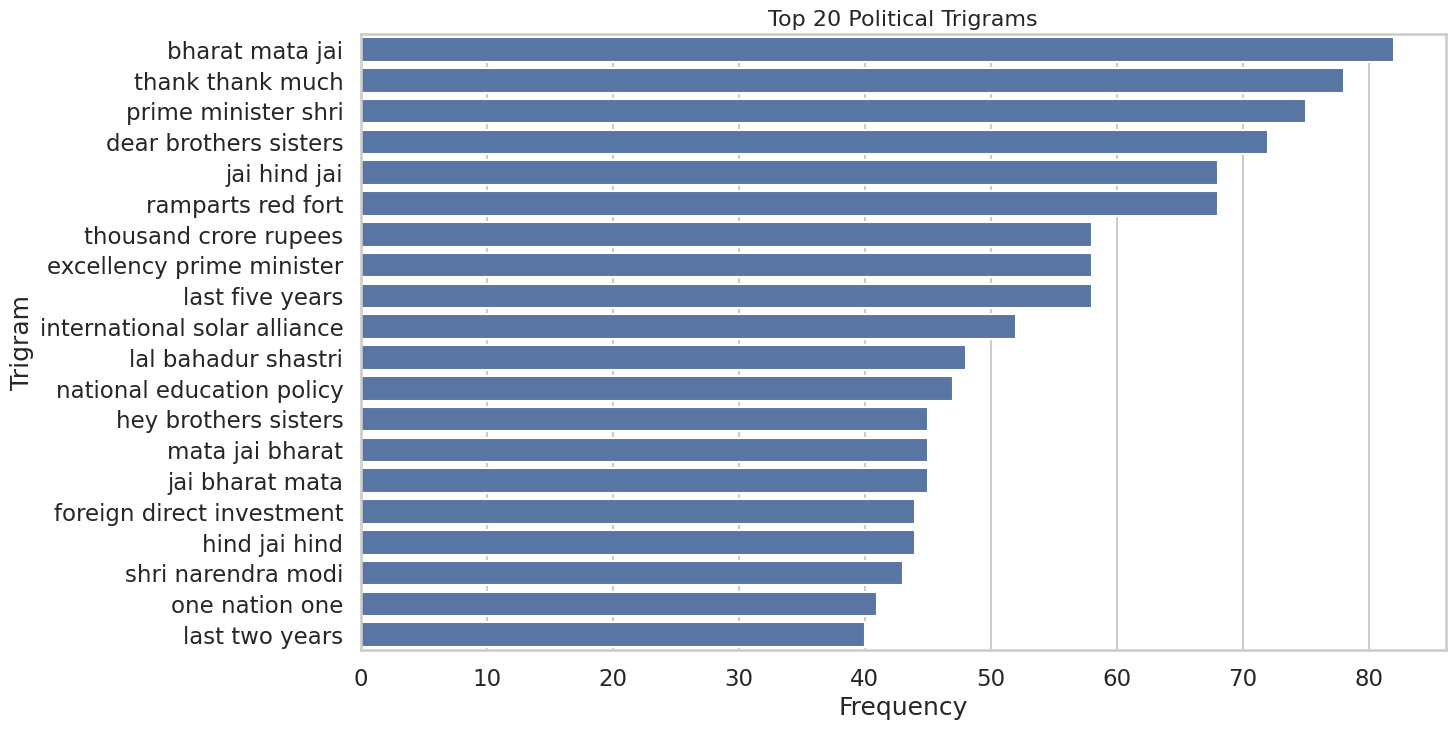

In [23]:
# ============================================================
# TRIGRAM ANALYSIS
# ============================================================

trigrams_list = list(ngrams(tokens, 3))

trigram_freq = Counter(trigrams_list)

top_trigrams = trigram_freq.most_common(20)

trigram_df = pd.DataFrame(
    top_trigrams,
    columns=['trigram', 'frequency']
)

trigram_df['trigram'] = trigram_df['trigram'].apply(
    lambda x: ' '.join(x)
)

plt.figure(figsize=(14,8))

sns.barplot(
    data=trigram_df,
    x='frequency',
    y='trigram'
)

plt.title(
    "Top 20 Political Trigrams",
    fontsize=16
)

plt.xlabel("Frequency")

plt.ylabel("Trigram")

plt.show()


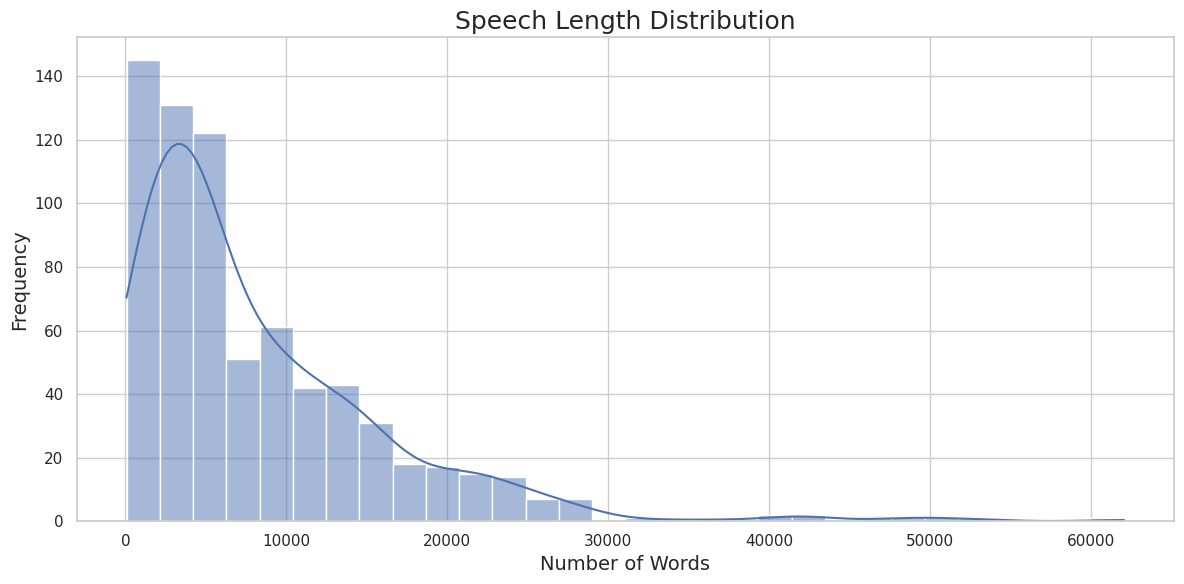

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

sns.histplot(
    data=df,
    x='words',
    bins=30,
    kde=True
)

plt.title(
    "Speech Length Distribution",
    fontsize=18
)

plt.xlabel(
    "Number of Words",
    fontsize=14
)

plt.ylabel(
    "Frequency",
    fontsize=14
)

plt.tight_layout()

plt.show()